EDA ON HEALTHCARE DATASET: PROJECT #1

In [1]:
##IMPORT NECESSARY LIBRARIES
from google.colab import files
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')
sns.set_palette("husl")

In [2]:
##IMPORTING FILE
print("IMPORTING DATASET....")
uploaded = files.upload()

IMPORTING DATASET....


Saving archive.zip to archive.zip


In [3]:
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
  zip_ref.extractall("health_data")

In [4]:
df = pd.read_csv("health_data/healthcare_dataset.csv")
print(f" ✅ Data loaded successfully!")

 ✅ Data loaded successfully!


In [5]:
# Shape of dataset
print("Rows, Columns:", df.shape)

# Column info
print("Columns:", df.columns.tolist(), "\n")
print("\nColumn Info:\n")
print(df.info())

# Summary statistics
print("\nSummary Statistics:\n")
print(df.describe(include="all").T)
df.head()

Rows, Columns: (55500, 15)
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results'] 


Column Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal



📊 Data Types and Missing Values:


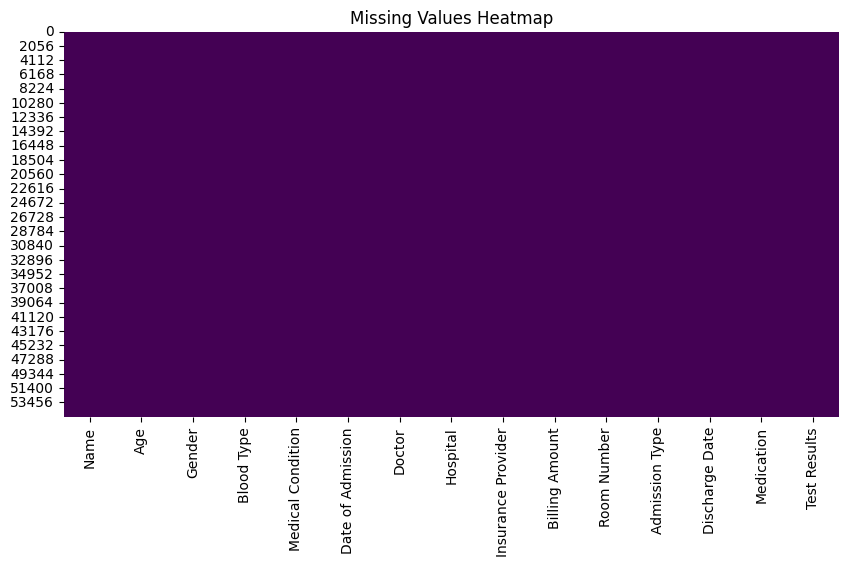

In [8]:
print("\n📊 Data Types and Missing Values:")
info_df = pd.DataFrame({
    'Column': df.columns,                                    # Changed to dfc
    'Data_Type': df.dtypes,                                 # Changed to dfc
    'Missing_Count': df.isnull().sum(),                     # Changed to dfc
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100, # Changed to dfc
    'Unique_Values': [df[col].nunique() for col in df.columns] # Changed to dfc
})

#Heatmap for missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")  # Changed to dfc
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
##DATA CLEANING AND PROCESSING
print("\nDATA CLEANING....\n")
dfc = df.copy()

##convert data columns
for col in ["Date of Admission", "Discharge Date"]:
    dfc[col] = pd.to_datetime(dfc[col], errors="coerce")


##billing to numeric (strip non-digits)
dfc["Billing Amount"] = (
    dfc["Billing Amount"]
    .astype(str)
    .str.replace(r"[^\d.\-]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

##calculate length of stay
dfc["Length of Stay (days)"] = (dfc["Discharge Date"] - dfc["Date of Admission"]).dt.days


##Data Validation and Warnings
print("\n DATA VALIDATION:")
if "Age" in dfc.columns:
  invalid_ages = ((dfc["Age"] < 0) | (dfc["Age"] > 120)).sum()
  if invalid_ages > 0:
    print(f"⚠️ Warning: {invalid_ages} records have invalid ages.")
    dfc.loc[(dfc["Age"] < 0) | (dfc["Age"] > 120), "Age"] = np.nan

if "Length of Stay (days)" in dfc.columns:
    negative_stays = (dfc["Length of Stay (days)"] < 0).sum()
    if negative_stays > 0:
        print(f"⚠️  Found {negative_stays} negative length of stays")
        dfc.loc[dfc["Length of Stay (days)"] < 0, "Length of Stay (days)"] = np.nan

print(dfc[["Age","Billing Amount","Length of Stay (days)"]].describe())

##MISSING VALUES
print("\nMISSING VALUE ANALYSIS: ")
missing = dfc.isnull().sum()
missing_with_percent = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': (missing / len(dfc)) * 100
})
missing_with_percent = missing_with_percent[missing_with_percent['Missing_Count'] > 0]

if len(missing_with_percent) > 0:
    print("Columns with missing values:")
    print(missing_with_percent.round(2))

    # Visualize missing values
    plt.figure(figsize=(12, 6))
    if len(missing_with_percent) > 0:
        plt.subplot(1, 2, 1)
        sns.heatmap(dfc.isnull(), cbar=True, cmap="viridis", yticklabels=False)
        plt.title("Missing Values Heatmap")

        plt.subplot(1, 2, 2)
        missing_with_percent['Missing_Percent'].plot(kind='bar')
        plt.title("Missing Values by Column (%)")
        plt.xticks(rotation=45)
        plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found!")


DATA CLEANING....


 DATA VALIDATION:
                Age  Billing Amount  Length of Stay (days)
count  55500.000000    55500.000000           55500.000000
mean      51.539459    25539.316097              15.509009
std       19.602454    14211.454431               8.659600
min       13.000000    -2008.492140               1.000000
25%       35.000000    13241.224652               8.000000
50%       52.000000    25538.069376              15.000000
75%       68.000000    37820.508436              23.000000
max       89.000000    52764.276736              30.000000

MISSING VALUE ANALYSIS: 
✅ No missing values found!


In [10]:
##EXPLORATORY DATA ANALYSIS

print("\nEXPLORATORY DATA ANALYSIS....")


EXPLORATORY DATA ANALYSIS....


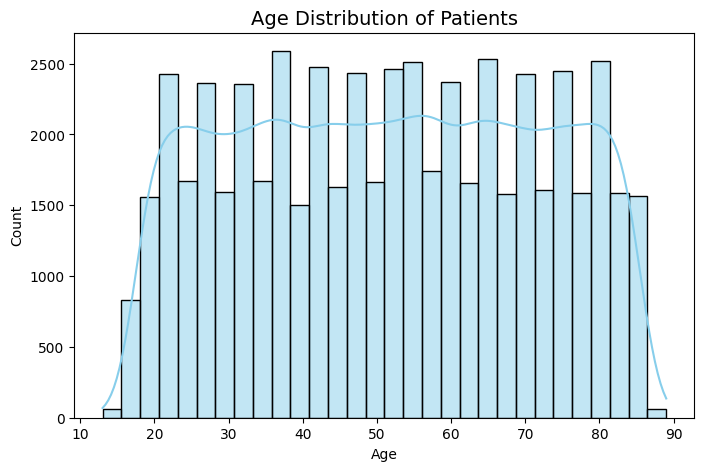

In [11]:

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color="skyblue")
plt.title("Age Distribution of Patients", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


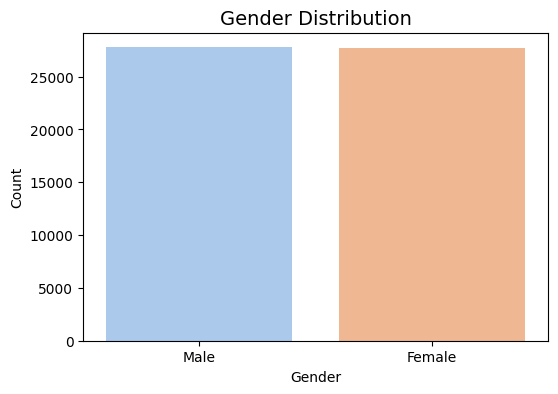

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=dfc, hue="Gender", palette="pastel", legend=False)
plt.title("Gender Distribution", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


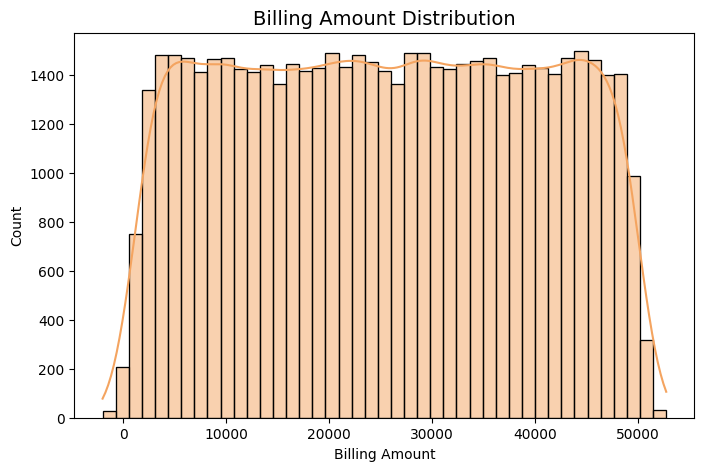

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(x="Billing Amount", data=dfc, kde=True, color="sandybrown")
plt.title("Billing Amount Distribution", fontsize=14)
plt.xlabel("Billing Amount")
plt.ylabel("Count")
plt.show()

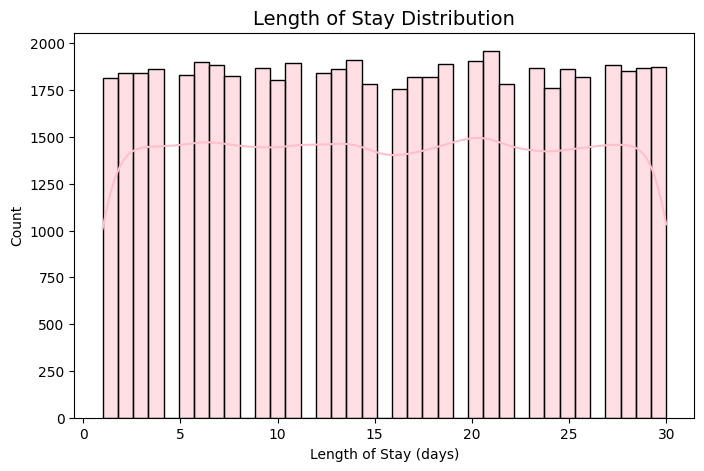

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(x="Length of Stay (days)", data=dfc, kde=True, color="pink")
plt.title("Length of Stay Distribution", fontsize=14)
plt.xlabel("Length of Stay (days)")
plt.ylabel("Count")
plt.show()

In [15]:
# Additional categorical analysis
categorical_cols = dfc.select_dtypes(include=['object']).columns
print(f"\n📋 Categorical Variables: {list(categorical_cols)}")

for col in categorical_cols[:3]:  # Show first 3 categorical columns
    if dfc[col].nunique() <= 10:  # Only show if not too many unique values
        print(f"\n{col} Value Counts:")
        print(dfc[col].value_counts().head())


📋 Categorical Variables: ['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor', 'Hospital', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']

Gender Value Counts:
Gender
Male      27774
Female    27726
Name: count, dtype: int64

Blood Type Value Counts:
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
Name: count, dtype: int64


In [16]:
print("SUMMARY\n")



print("Dataset Overview:")
print(f"• Total Records: {len(dfc):,}")
print(f"• Total Features: {len(dfc.columns)}")
print(f"• Numerical Features: {len(dfc.select_dtypes(include=[np.number]).columns)}")
print(f"• Categorical Features: {len(dfc.select_dtypes(include=['object']).columns)}")
print(f"• Date Features: {len(dfc.select_dtypes(include=['datetime64']).columns)}")

if "Age" in dfc.columns:
    age_stats = dfc['Age'].describe()
    print(f"• Age Range: {age_stats['min']:.0f} - {age_stats['max']:.0f} years")
    print(f"• Average Age: {age_stats['mean']:.1f} years")

if "Length of Stay (days)" in dfc.columns:
    los_stats = dfc['Length of Stay (days)'].describe()
    print(f"• Average Length of Stay: {los_stats['mean']:.1f} days")

print("\n✅ Analysis Complete!")


SUMMARY

Dataset Overview:
• Total Records: 55,500
• Total Features: 16
• Numerical Features: 4
• Categorical Features: 10
• Date Features: 2
• Age Range: 13 - 89 years
• Average Age: 51.5 years
• Average Length of Stay: 15.5 days

✅ Analysis Complete!


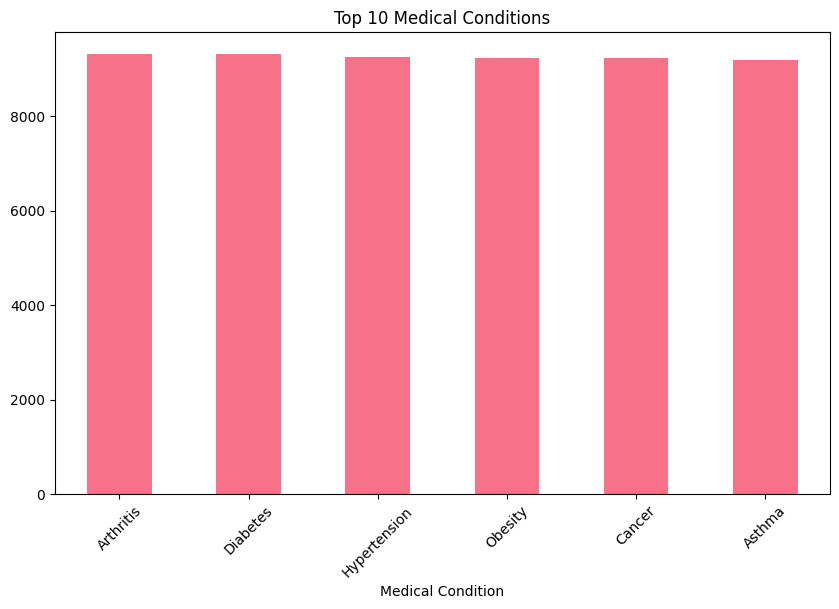

In [17]:
# Most common medical conditions
plt.figure(figsize=(10,6))
condition_counts = dfc['Medical Condition'].value_counts().head(10)
condition_counts.plot(kind='bar')
plt.title("Top 10 Medical Conditions")
plt.xticks(rotation=45)
plt.show()

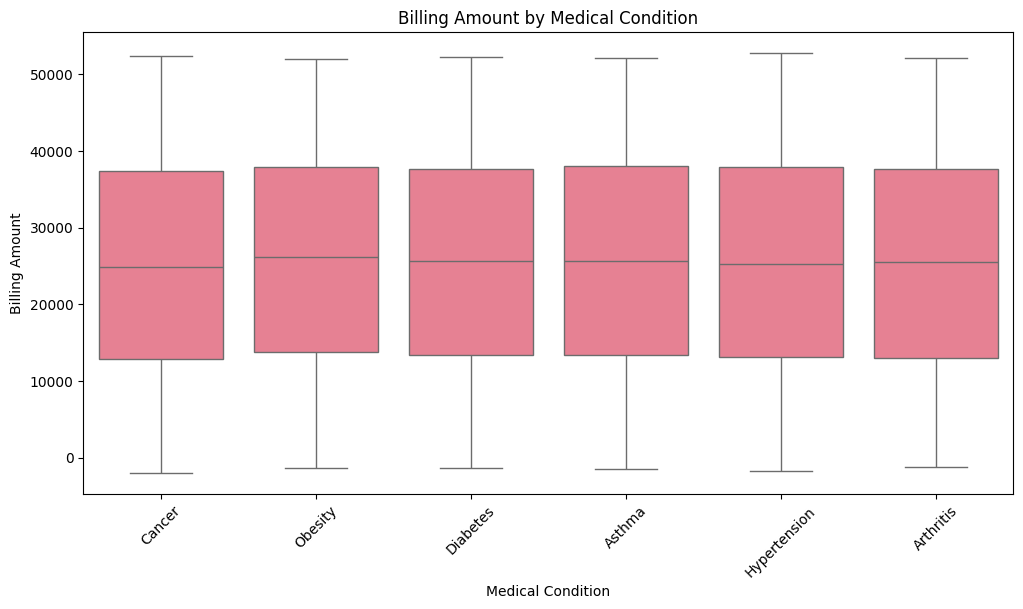

In [18]:
# Billing by medical condition
plt.figure(figsize=(12,6))
sns.boxplot(data=dfc, x='Medical Condition', y='Billing Amount')
plt.xticks(rotation=45)
plt.title("Billing Amount by Medical Condition")
plt.show()

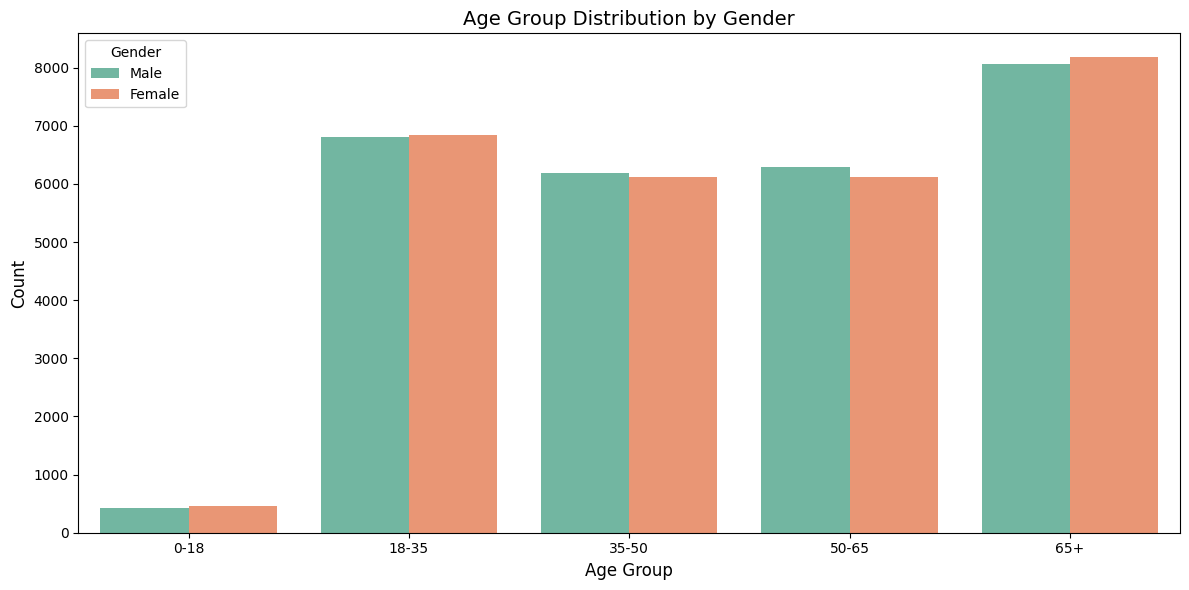

In [19]:
# Age groups analysis
plt.figure(figsize=(12,6))
dfc['Age Group'] = pd.cut(dfc['Age'], bins=[0,18,35,50,65,100],
                         labels=['0-18','18-35','35-50','50-65','65+'])
sns.countplot(data=dfc, x='Age Group', hue='Gender', palette='Set2')
plt.title("Age Group Distribution by Gender", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [20]:
print("📊 KEY INSIGHTS:")
print(f"• Most expensive condition: {dfc.groupby('Medical Condition')['Billing Amount'].mean().idxmax()}")
print(f"• Longest average stay: {dfc.groupby('Medical Condition')['Length of Stay (days)'].mean().idxmax()}")
print(f"• Average patient age: {dfc['Age'].mean():.1f} years")
print(f"• Total patients analyzed: {len(dfc):,}")

📊 KEY INSIGHTS:
• Most expensive condition: Obesity
• Longest average stay: Asthma
• Average patient age: 51.5 years
• Total patients analyzed: 55,500
